## Student Name: 

---

# Tutorial 1: probabilistic computations

All the parts that require action (either in the code or equations) are flagged by `<your turn>` or $\color{red}{<your~turn>}$

In [19]:
import numpy as np
import scipy.stats as st
import pandas as pd
import seaborn as sns
import pymc as pm
import arviz as az
import matplotlib.pylab as plt

sns.set_style("darkgrid")
sns.set_context("talk")
sns.color_palette("hls", 8)

# Setting matplotlib fonts
from matplotlib import rc
font = {'family': 'serif',
        'weight': 'bold',
        'size': '14'}
rc('font', **font)


# Below is a set of colors for matplotlib that is colorblind-friendly
# To use them in plotting commands, you can simply set "color=colorset[N]",
# where N is an integer in [0,16), reflecting the index of the colors below.
COLORSET = ['#000000','#00270C','#00443C','#005083',
            '#034BCA','#483CFC','#9C2BFF','#EB24F4',
            '#FF2DC2','#FF4986','#FF7356','#FFA443',
            '#EBD155','#D3F187','#D7FFC8','#FFFFFF']

## Motivation: Algebra of random variables and probabilistic computation

When dealing with algebra of random variables, we are no longer *just* interested in a single value, but also what their distribution dictates on the results. For example:

If X and Y are two random variables with distributions $p_X(X)$ and $p_Y(Y)$, we might be interested in $Z = X+Y$ which itself is a random variable. 

For example, if 

$$ X\sim \textrm{Normal}(\mu_X,\sigma_X) $$
$$ Y\sim \textrm{Normal}(\mu_Y,\sigma_Y) $$

and if $X$ and $Y$ are independent, then, one can show that

$$ Z \sim \textrm{Normal}(\mu_X+\mu_Y,\sqrt{\sigma_X^2 + \sigma_Y^2})$$

You might recall this is similar to error propagation (in fact it is the underlying algebra of it). While analytical proofs are the ultimate goal and the ideal solution, they are not always practical, so an alternative approach is to approximate a distribution through sampling.

### Monte Carlo simulation for random variable algebra
Assume $X\sim \textrm{Normal}(\mu_X=5,\sigma_X=3) $ and $Y\sim \textrm{Normal}(\mu_Y=15,\sigma_Y=5)$. We define $Z=X+Y$. 

#### Exercise - part a: Using tools available in `scipy.stats` (e.g., see [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html#scipy.stats.norm)), perform Monte Carlo sampling from the distribution of $Z$.

In [2]:
# <your turn>
MC_sample_size = 10000

X_sample = st.norm(loc=5, scale=3).rvs(MC_sample_size)
Y_sample = st.norm(loc=15, scale=5).rvs(MC_sample_size)
Z_sample = X_sample + Y_sample

print('Type of Z_sample:\n', type(Z_sample))
print('Shape of Z_sample:\n', Z_sample.shape)
print('A glimpse of Z_sample:\n',Z_sample)

Type of Z_sample:
 <class 'numpy.ndarray'>
Shape of Z_sample:
 (10000,)
A glimpse of Z_sample:
 [28.00818801 27.43773802 23.80149773 ... 13.4059066  15.52201608
 15.18955152]


#### Exercise - part b: Make a histogram of the resulting MC sample of $Z$.

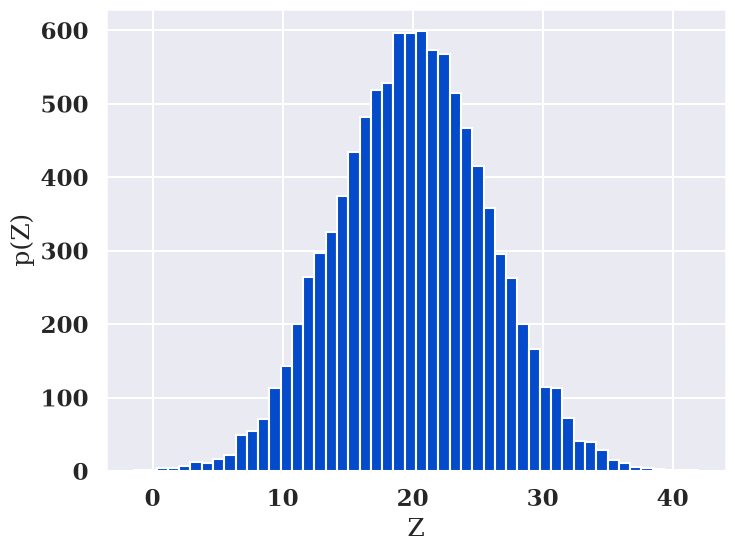

In [20]:
# <your turn>
# Output should be a single plot

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
# <your turn>

ax.hist(Z_sample, bins=50, color=COLORSET[4])

# Plot cosmetics
ax.set_xlabel('Z')
ax.set_ylabel('p(Z)');

#### Exercise - part c: Generate a curve representing $p(Z)$ based on the analytical form discussed in the earlier dicussion. Plot this analytical form on top of the histogram from part b and compare.

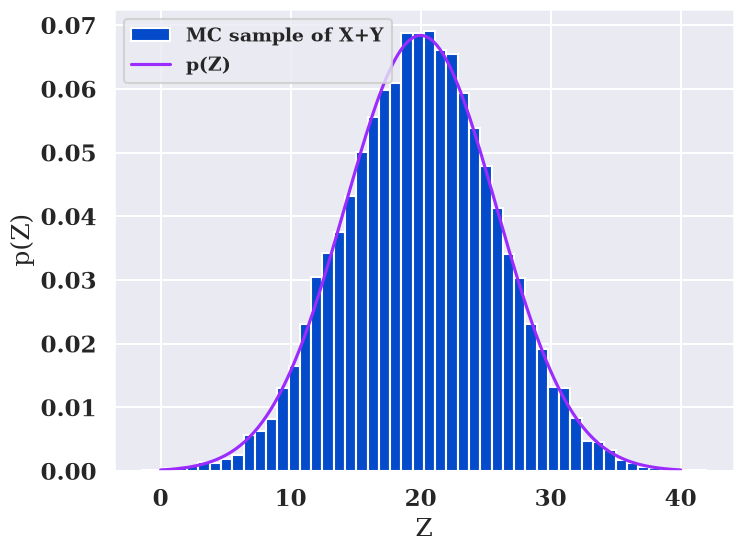

In [23]:
# <your turn>
# Output should be a single plot

theoretical_Z = np.linspace(0, 40, 1000)
theoretical_pZ = st.norm(loc=20,scale=np.sqrt(3**2+5**2)).pdf(theoretical_Z)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
# <your turn>

ax.hist(Z_sample,density=True, bins=50, label='MC sample of X+Y', color=COLORSET[4])
ax.plot(theoretical_Z,theoretical_pZ, label='p(Z)', color=COLORSET[6])
ax.legend(loc=2,fontsize=14)
# Plot cosmetics
ax.set_xlabel('Z')
ax.set_ylabel('p(Z)');

Broadly speaking, in this workshop we are interested in a more generalized numerical method to calculate distribution of variables like $Z$ as a gateway to our probabilistic inference. 

## Probabilistic computations and probabilistic languages

Naively, a probabilistic computer language is a language that allows definition of random variables and performing of algebraic operations on such variables, to enable probabilistic computation. What we did using `scipy.stats` was a simple version of what a probabilistic language can help us with. However, our apprach with `scipy.stats` starts to unravel if we are dealing with ill-normalized distributions (remember the problem with model evidence and normalization of posterior probability density?).

So, let's perform a similar task as we did above, but in a probabilistic language. We will use a probabilistic language built in Python called [PyMC](https://www.pymc.io/welcome.html).

### First steps in PYMC
We define the following random variables:

$$ X \sim \rm{Normal}(\mu=5,\sigma=2) $$
$$ Y \sim \rm{Laplace(\mu=2,b=1)}$$

We define $Z= XY$, and we are interested in its probability distribution.

#### Exercise - part a: Have a look at how PYMC [defines random variable](https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/pymc_overview.html#model-specification) and how it parameterizes a [Laplace distribution](https://www.pymc.io/projects/docs/en/latest/api/distributions/generated/pymc.Laplace.html) and define random variables $X,Y,Z$ based on the distributions above.

In [5]:
# <your turn>
# This cell has no output

with pm.Model() as my_first_model:
    X = pm.Normal('X',mu=5, sigma=2)
    Y = pm.Laplace('Y',mu=2, b=1)
    Z = pm.Deterministic('Z', X*Y)

#### Exercise - part b: Print and explore the computational "type" of your defined variables.

In [6]:
# <your turn>
X

X

In [7]:
type(X)

pytensor.tensor.variable.TensorVariable

#### Exercise - part c: Perform MC sampling for all three variables. Have a look at `pm.sample` [documentation](https://www.pymc.io/projects/docs/en/stable/api/generated/pymc.sample.html).

In [8]:
# <your turn>
# This cell will print outputs automatically about sampling progression

with my_first_model:
    mc_sample = pm.sample(draws=MC_sample_size)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [X, Y]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 7 seconds.


We will explore the computational details of the output above shortly, but for now, let's treat it a little superficially:

#### Exercise - part d: Explore the output of sampling. Hint: have a look at documentation of [inference data](https://python.arviz.org/en/latest/getting_started/WorkingWithInferenceData.html).

In [9]:
# <your turn>

mc_sample

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 4, draw: 10000)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 80kB 0 1 2 3 4 5 6 ... 9994 9995 9996 9997 9998 9999
│       Data variables:
│           X        (chain, draw) float64 320kB 4.727 0.3917 0.3917 ... 2.917 5.737
│           Y        (chain, draw) float64 320kB 1.791 1.616 1.616 ... 2.024 2.161 2.236
│           Z        (chain, draw) float64 320kB 8.467 0.633 0.633 ... 8.877 6.304 12.83
│       Attributes:
│           created_at:                 2026-07-24T00:23:34.496491+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              6.90270209312439
│           tuning_steps:               1000
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 10000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 80kB 0 1 2 3 4 ... 9996 9997 9998 9999
│       Data variables: (12/18)
│           energy                 (chain, draw) float64 320kB 2.531 7.401 ... 4.589
│           lp                     (chain, draw) float64 320kB -2.523 -5.344 ... -2.609
│           n_steps                (chain, draw) float64 320kB 3.0 7.0 5.0 ... 3.0 3.0
│           perf_counter_diff      (chain, draw) float64 320kB 0.0003754 ... 0.0001474
│           step_size_bar          (chain, draw) float64 320kB 0.668 0.668 ... 0.6983
│           index_in_trajectory    (chain, draw) int64 320kB -1 -3 0 -3 -4 ... 1 1 -3 1
│           ...                     ...
│           perf_counter_start     (chain, draw) float64 320kB 1.52e+05 ... 1.52e+05
│           reached_max_treedepth  (chain, draw) bool 40kB False False ... False False
│           divergences            (chain, draw) int64 320kB 0 0 0 0 0 0 ... 0 0 0 0 0 0
│           step_size              (chain, draw) float64 320kB 0.7529 0.7529 ... 1.129
│           energy_error           (chain, draw) float64 320kB -0.03253 ... -0.05369
│           largest_eigval         (chain, draw) float64 320kB nan nan nan ... nan nan
│       Attributes:
│           created_at:                 2026-07-24T00:23:34.545576+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              6.90270209312439
│           tuning_steps:               1000
└── Group: /observed_data
        Attributes:
            created_at:                 2026-07-24T00:23:34.548954+00:00
            creation_library:           ArviZ
            creation_library_version:   1.2.0
            creation_library_language:  Python
            inference_library:          pymc
            inference_library_version:  6.2.0
            sample_dims:                []

In [10]:
mc_sample.posterior['X'].to_numpy()

array([[4.72694096, 0.39173723, 0.39173723, ..., 1.78816728, 5.78836066,
        5.57167765],
       [4.00405464, 5.67662136, 5.81013238, ..., 6.01659516, 4.05258151,
        6.08193882],
       [2.64521936, 4.46644821, 4.95947016, ..., 5.20401122, 5.89321987,
        6.9521119 ],
       [2.90742936, 4.98122467, 4.4578252 , ..., 4.38681227, 2.91718095,
        5.73731118]], shape=(4, 10000))

### Inspecting MC (and MCMC) outputs efficiently

PYMC ecosystem provides a lot of effective tools to explore our inference and outputs. Here we will use [Arviz](https://python.arviz.org/en/latest/index.html) to visuaize our reuslts.

Arviz uses a "backend-agnostic" framework for visualisation, which might make the commands appear cumbersome at first. The approach is explained [here](https://python.arviz.org/projects/plots/en/v1.2.0/tutorials/overview.html). 

#### Exercise - part a: Have a look at the documentation of [`plot_dist`](https://python.arviz.org/projects/plots/en/stable/api/generated/arviz_plots.plot_dist.html) (an example [here](https://python.arviz.org/projects/plots/en/latest/gallery/plot_dist_kde.html)) in Arviz and plot the results of our sampling using that. Explore how $Z$ looks based on the original premise of our "model" ($Z=XY$).

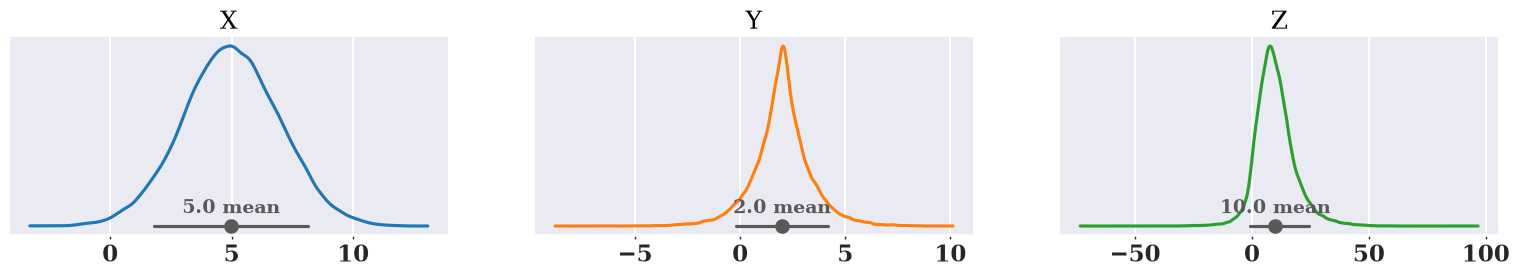

In [42]:
# <your turn>

az.plot_dist(mc_sample,
             aes={"color": ["__variable__"]}) # Map the color to the variable

#### Exercise - part b: Have a look at the documentation of [`plot_pair`](https://python.arviz.org/en/latest/api/generated/arviz.plot_pair.html#arviz.plot_pair) (an example at the bottom of that page) in Arviz and plot the results of our sampling using that. Explore what the plot represents regarding joint and marginal distributions.

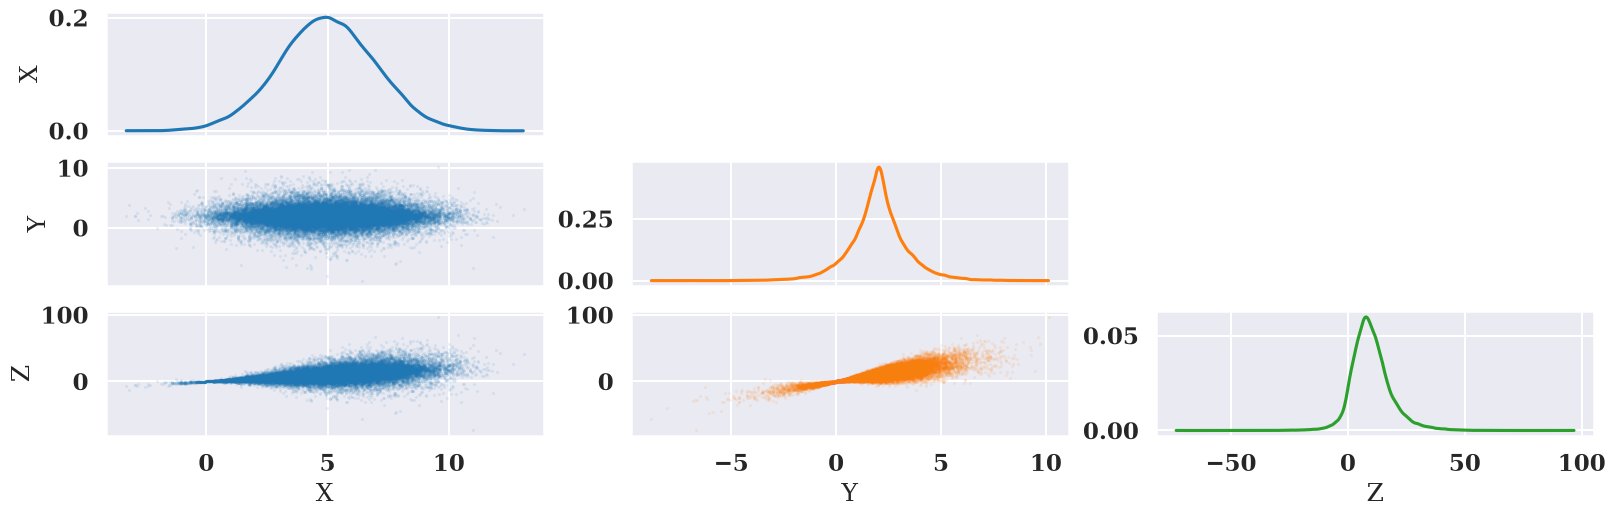

In [45]:
# <your turn>

az.plot_pair(mc_sample,
             aes={"color": ["__variable__"]},
             visuals={"scatter": {"size":5, "alpha":0.1}}  # Markers smaller and more transparent for scatter plot
            )

### Another quick but perhaps counter-intuituve example

We define:

$$ X\sim\textrm{Uniform}(\min=0,\max=5)$$
$$ Z = X^2 $$

#### Exercise: First think about what would $p(Z)$ look like, then sample and visualize to check if you were correct.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [X]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 6 seconds.


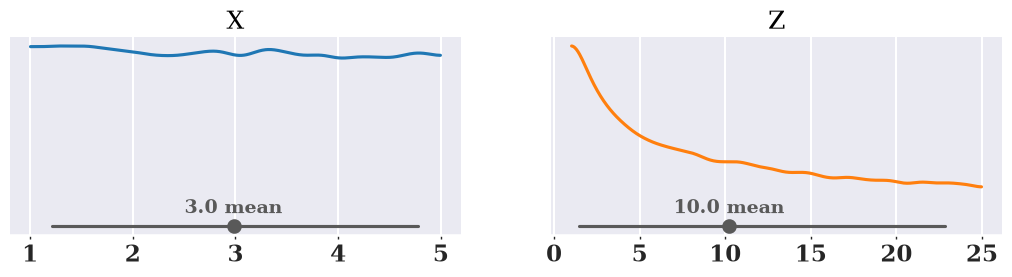

In [47]:
# <your turn>
# Make a model, sample, then plot.

with pm.Model() as my_second_model:
    X = pm.Uniform('X', lower=1, upper=5)
    Z = pm.Deterministic('Z', X**2)
    mc_sample = pm.sample(draws=MC_sample_size)

## Plotting doesn't need to be in the model "context", put it below here.

az.plot_dist(mc_sample,
             aes={"color": ["__variable__"]})

### Hierarchical random variables

In the cases above, we mostly performed simple arithmetic. But random variable algebra can get a bit more complex. For example, imagine we define the following quantities and  **hierarchy**:

$$ \nu_{\rm{H}} \sim \textrm{Lorentz}(\mu_L=10, \sigma_L=1) $$

$$ T \sim \textrm{laplace}(\mu_T = 100, b_T = 10)$$

$$ \nu_{\rm{obs}} \sim \textrm{Normal}(\mu_{\rm{obs}}=\nu_{\rm{H}}, \sigma_{\rm{obs}}=\sqrt{T}) $$

*This is a naive model for the impact of [lifetime broadening](https://en.wikipedia.org/wiki/Spectral_line#Natural_broadening) and [thermal broadening](https://en.wikipedia.org/wiki/Doppler_broadening) on width of spectral lines.*

#### Exercise: Use PyMC to model how these physical effects (random variables) influence each other and plot their density using `plot_density`.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [nu_H, T, nu_T]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 24 seconds.


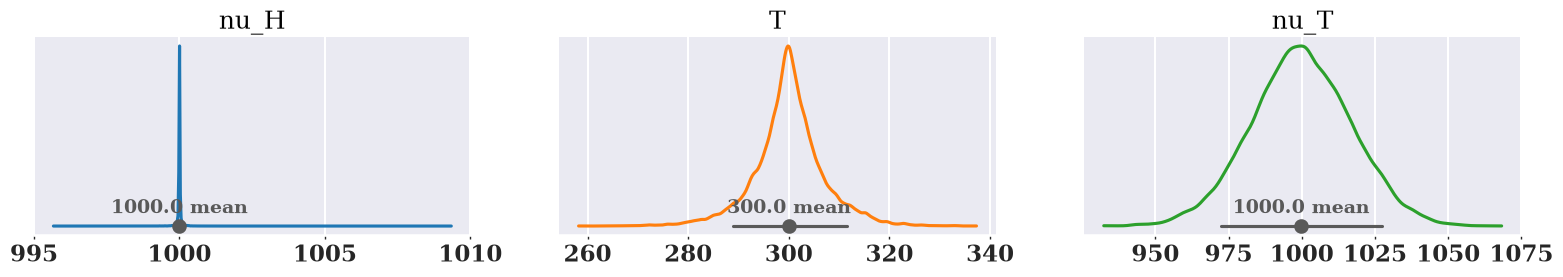

In [48]:
# <your turn>
# Make a model, sample, then plot.

with pm.Model() as my_line_model:
    nu_H = pm.Cauchy('nu_H', alpha=1000, beta=0.01)
    T = pm.Laplace('T', mu=300, b=5)
    nu_T = pm.Normal('nu_T', mu=nu_H, sigma=T**0.5)
    mc_sample = pm.sample(draws=MC_sample_size)

## Plotting doesn't need to be in the model "context", put it below here.

az.plot_dist(mc_sample,
             aes={"color": ["__variable__"]})

Assuming a very low temperature:
$$ T\sim \rm{Exponential}(\lambda=100) $$

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [nu_H, T, nu_T]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 15 seconds.
There were 369 divergences after tuning. Increase `target_accept` or reparameterize.


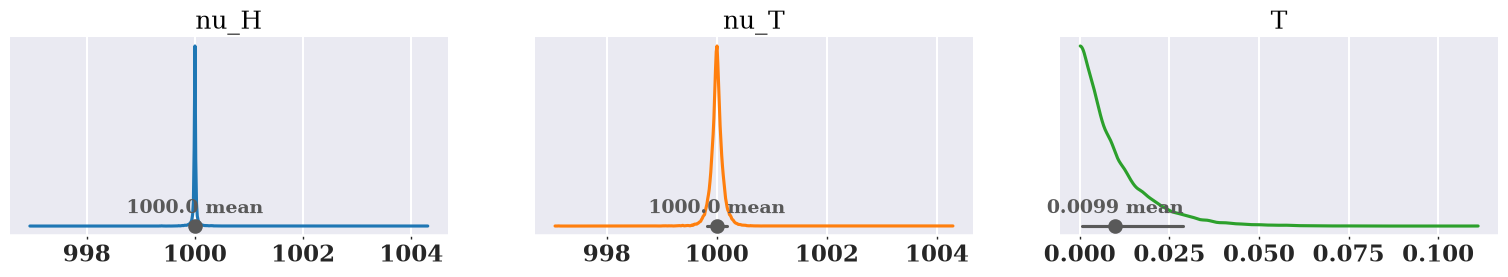

In [49]:
# <your turn>
# Make a model, sample, then plot.

with pm.Model() as my_line_model:
    nu_H = pm.Cauchy('nu_H', alpha=1000, beta=0.01)
    T = pm.Exponential('T', lam=100)
    nu_T = pm.Normal('nu_T', mu=nu_H, sigma=T**0.5)
    mc_sample = pm.sample(draws=MC_sample_size)

## Plotting doesn't need to be in the model "context", put it below here.

az.plot_dist(mc_sample,
             aes={"color": ["__variable__"]})

We will apply our tools on probabilistic computation to our problems in inference in the next tutorial.

## You can now save the notebook and download it.